In [1]:
import numpy as np
from numba import njit
import matplotlib.pyplot as plt

# import scienceplots

# plt.style.use('science')

$$
\partial_t \rho + \nabla \cdot [\rho \mathbf{P} - D \nabla \rho] = 0
$$

$$
\partial_t \mathbf{P} = a\, \mathbf{P} - b\, |\mathbf{P}|^2 \mathbf{P} + K \nabla^2 \mathbf{P} + \mu \mathbf{q}
$$

$$
\partial_t \mathbf{q} = \frac{\rho \mathbf{P}}{f} \left( 1 - \mathbf{q}^2\right)
$$

5.604974894486315


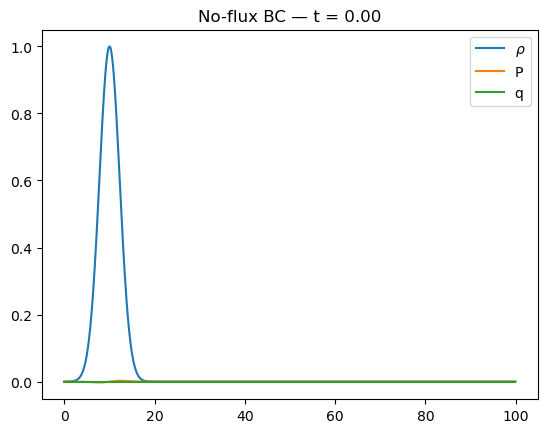

5.604980911246145


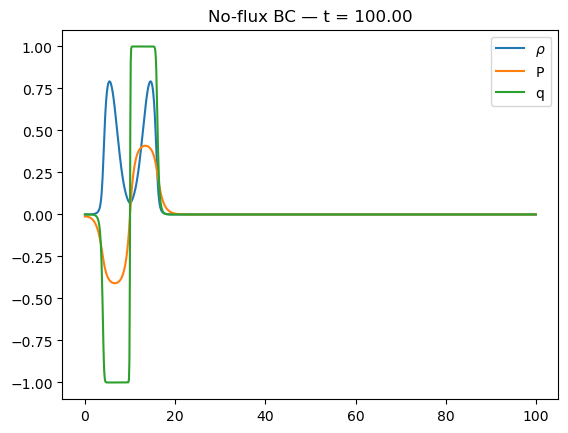

5.604921824633069


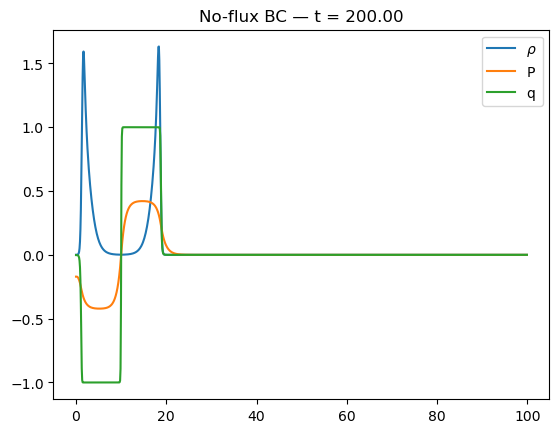

3.101813143206537


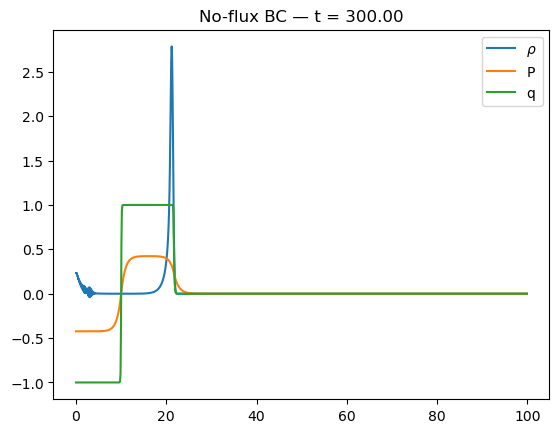

2.8080457301053


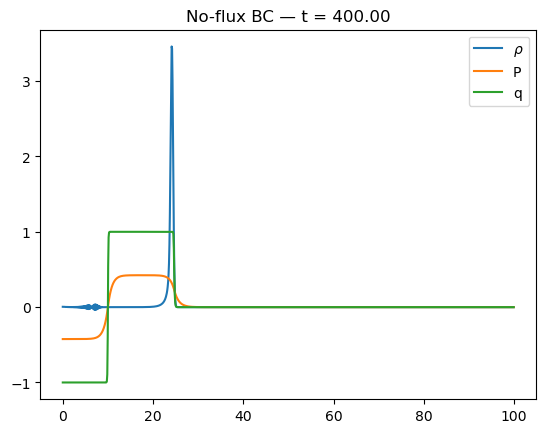

In [81]:
# Parameters
Nx = 1024
Lx = 100.0
dx = Lx / Nx
dt = 0.001
Nt = 500_000

# Model parameters
a = -1.0
b = 1.0
K = 1.0
mu = 0.5
f = 1.0
D = 1.0

x = np.linspace(0, Lx, Nx, endpoint=False)

# Initial conditions
ci_rho = lambda x: np.exp(-(x - 10) ** 2 / 10)

rho = ci_rho(x)
P = -0.1 * np.gradient(rho)
q = np.zeros(Nx)

# ---------- Neumann boundary helper ----------
@njit
def apply_neumann(u):
    """Apply zero-flux (Neumann) BCs: du/dx = 0 at both boundaries."""
    # u[2] = 0
    # u[-3] = 0
    
    u[1] = u[2]
    u[0] = u[1]

    u[-2] = u[-3]
    u[-1] = u[-2]
# ---------- Spatial derivatives (no periodic rolls) ----------
@njit
def grad(u, dx):
    du = np.empty_like(u)
    # Central differences for interior
    du[1:-1] = (u[2:] - u[:-2]) / (2 * dx)
    # Neumann BC (zero flux)
    #du[0] = 0.0
    #du[-1] = 0.0
    return du

@njit
def laplacian(u, dx):
    N = u.shape[0]
    lap = np.empty_like(u)
    # interior
    for i in range(1, N-1):
        lap[i] = (u[i+1] - 2.0*u[i] + u[i-1]) / (dx*dx)
    # Neumann (zero gradient) -> mirror neighbors
    # we set second derivative at boundary equal to interior neighbor
    lap[0]   = (u[1] - 2.0*u[0] + u[1]) / (dx*dx)   # u[-1]=u[1]
    lap[-1]  = (u[-2] - 2.0*u[-1] + u[-2]) / (dx*dx)
    return lap


@njit
def compute_rho_rhs_conservative(rho, P, dx, D):
    """
    Finite-volume conservative flux for rho with diffusion.
    ∂t rho = -∂x [rho*P - D_rho ∂x rho]
    """
    rhoP = rho * P
    N = len(rhoP)

    grad_rho = grad(rho, dx)

    # Total flux at faces: F = rho*P - D_rho * grad_rho
    # Compute F at the off lattice points taking average

    F = np.empty(N+1)
    F[0] = 0.0
    for i in range(1, N):
        F[i] = 0.5 * ((rhoP[i-1] - D * grad_rho[i-1]) + (rhoP[i] - D * grad_rho[i]))
    F[N] = F[0]


    # Divergence of flux
    drho = np.empty_like(rho)
    for i in range(N):
        drho[i] = - (F[i+1] - F[i]) / dx

    drho[0] = 0
    drho[1] = 0
    drho[-1] = 0
    drho[-2] = 0

    # print(np.sum(drho))

    return drho


# ---------- RHS ----------
@njit
def rhs(rho, P, q, a, b, K, mu, f, D, dx):
    # apply_neumann(rho)
    apply_neumann(P)
    apply_neumann(q)

    drho = compute_rho_rhs_conservative(rho, P,  D, dx)
    dP = a*P - b*P**3 + K*laplacian(P, dx) + mu*q
    dq = rho * P / f * (1 - q ** 2)
    return drho, dP, dq

# ---------- RK4 time step ----------
@njit
def rk4_step(rho, P, q, a, b, K, mu, f, D, dx, dt):
    k1_r, k1_P, k1_q = rhs(rho, P, q, a, b, K, mu, f, D, dx)
    k2_r, k2_P, k2_q = rhs(rho + 0.5*dt*k1_r, P + 0.5*dt*k1_P, q + 0.5*dt*k1_q, a, b, K, mu, f, D, dx)
    k3_r, k3_P, k3_q = rhs(rho + 0.5*dt*k2_r, P + 0.5*dt*k2_P, q + 0.5*dt*k2_q, a, b, K, mu, f, D, dx)
    k4_r, k4_P, k4_q = rhs(rho + dt*k3_r, P + dt*k3_P, q + dt*k3_q, a, b, K, mu, f, D, dx)

    rho_new = rho + (dt/6)*(k1_r + 2*k2_r + 2*k3_r + k4_r)
    P_new   = P   + (dt/6)*(k1_P + 2*k2_P + 2*k3_P + k4_P)
    q_new   = q   + (dt/6)*(k1_q + 2*k2_q + 2*k3_q + k4_q)

    apply_neumann(rho_new)
    apply_neumann(P_new)
    apply_neumann(q_new)

    return rho_new, P_new, q_new

rho_t = []
P_t = []
q_t = []

rho_t.append(rho)
P_t.append(P)
q_t.append(q)

# ---------- Time evolution ----------
for n in range(Nt):
    rho, P, q = rk4_step(rho, P, q, a, b, K, mu, f, D, dx, dt)

    if n % 1000 == 0:
        
        rho_t.append(rho)
        P_t.append(P)
        q_t.append(q)
    if n % 100_000 == 0:
        print(np.sum(rho)*dx)
        plt.clf()
        plt.plot(x, rho, label=r'$\rho$')
        plt.plot(x, P, label='P')
        plt.plot(x, q, label='q')
        plt.legend()
        plt.title(f"No-flux BC — t = {n*dt:.2f}")
        plt.pause(0.01)

plt.show()

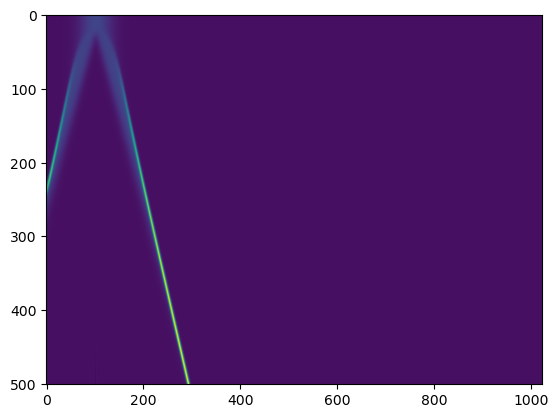

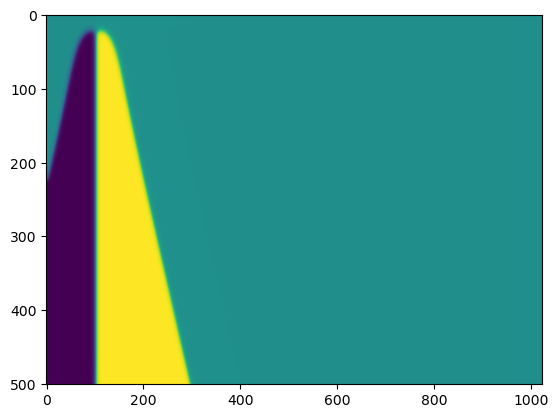

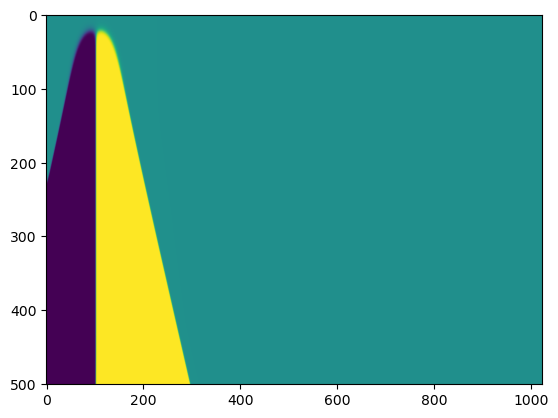

57.394931218621146 28.69748890574164


In [18]:
plt.imshow(rho_t, aspect='auto')
plt.show()

plt.imshow(P_t, aspect='auto')
plt.show()

plt.imshow(q_t, aspect='auto')
plt.show()


print(np.sum(rho_t[0]), np.sum(rho_t[-1]))

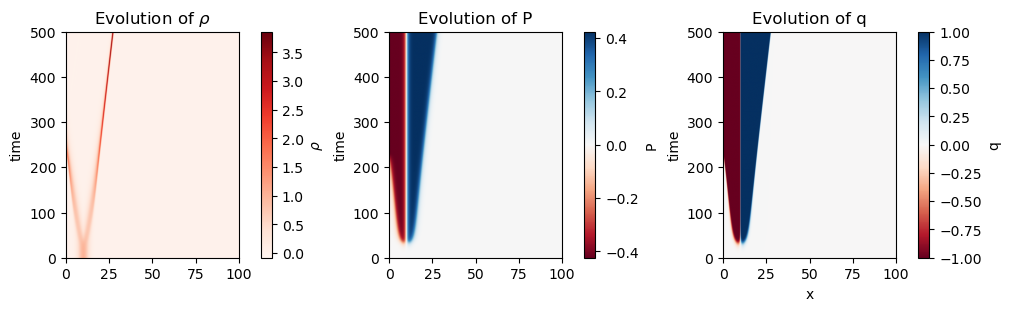

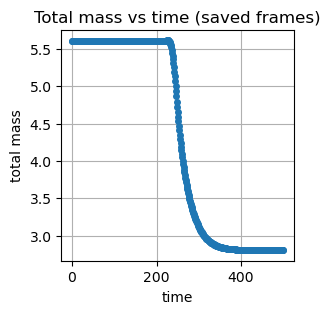

In [82]:
# stack saved snapshots (rho_t, P_t, q_t are lists of 1D arrays)
rho_arr = np.vstack(rho_t)   # shape (nt_save, Nx)
P_arr   = np.vstack(P_t)
q_arr   = np.vstack(q_t)

nt_save = rho_arr.shape[0]


save_interval_steps = 1000
times = np.arange(nt_save) * (dt * save_interval_steps)

extent = [x[0], x[-1] + dx, times[0], times[-1]]  # x axis left->right, y axis time increasing upward
fig, axs = plt.subplots(1, 3, figsize=(10,3), constrained_layout=True)
im0 = axs[0].imshow(rho_arr, aspect='auto', extent=extent, origin='lower', cmap='Reds')
axs[0].set_ylabel('time')
axs[0].set_title(r'Evolution of $\rho$')
fig.colorbar(im0, ax=axs[0], label=r'$\rho$')

im1 = axs[1].imshow(P_arr, aspect='auto', extent=extent, origin='lower', cmap='RdBu')
axs[1].set_ylabel('time')
axs[1].set_title('Evolution of P')
fig.colorbar(im1, ax=axs[1], label='P')

im2 = axs[2].imshow(q_arr, aspect='auto', extent=extent, origin='lower', cmap='RdBu')
axs[2].set_xlabel('x')
axs[2].set_ylabel('time')
axs[2].set_title('Evolution of q')
fig.colorbar(im2, ax=axs[2], label='q')

plt.show()

# plot total mass over saved frames to check conservation
mass = [np.sum(r)*dx for r in rho_t]
plt.figure(figsize=(3,3))
plt.plot(times, mass, '-o', markersize=4)
plt.xlabel('time')
plt.ylabel('total mass')
plt.title('Total mass vs time (saved frames)')
plt.grid(True)
plt.show()

### other version

5.604972674957062


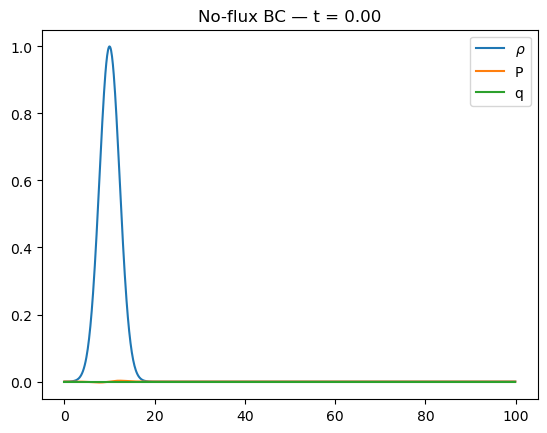

5.605098932872522


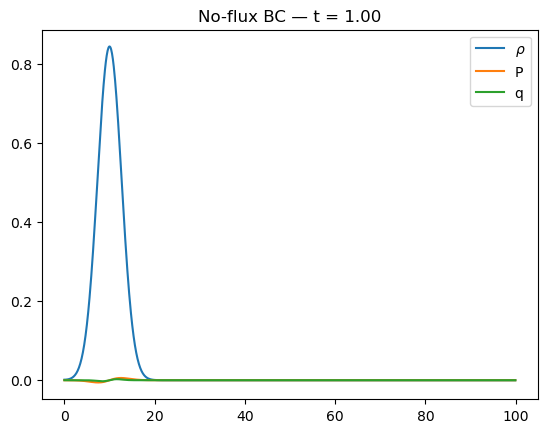

5.605535124493595


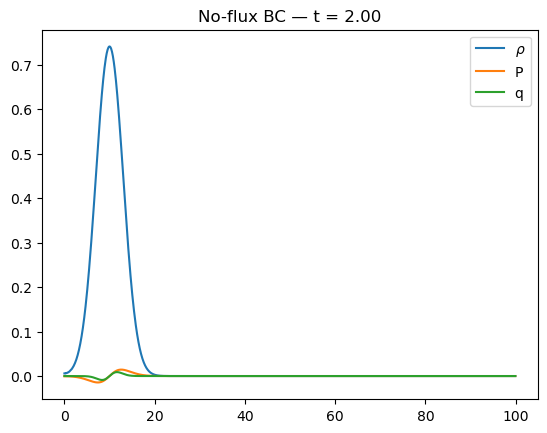

5.6063647492455


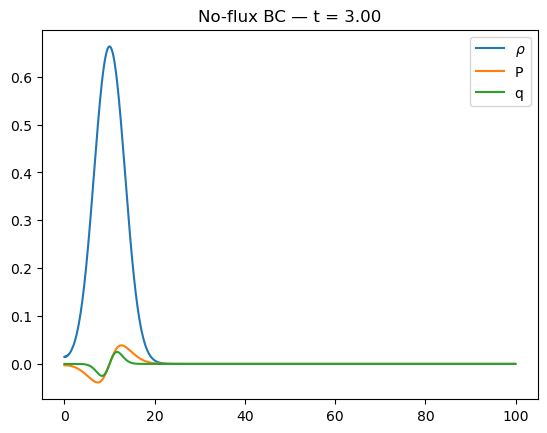

5.607442874948834


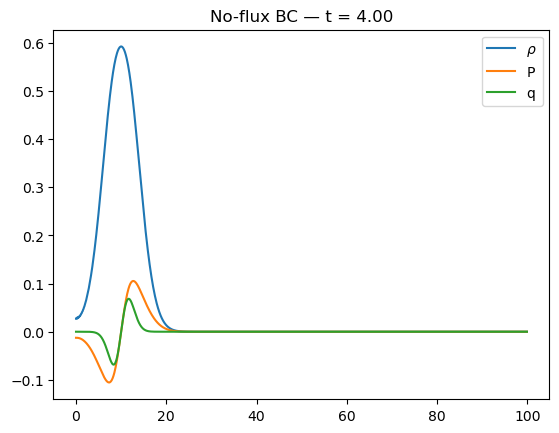

5.608043848066762


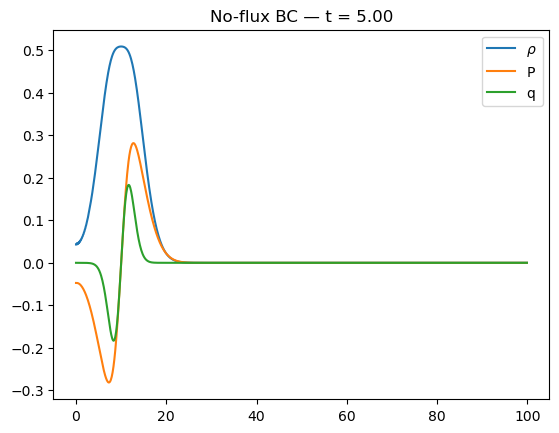

5.604902412185582


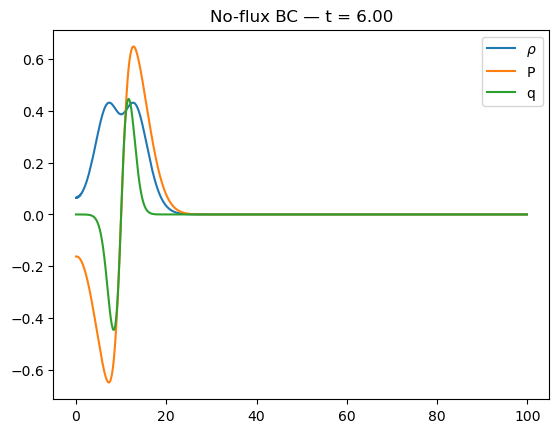

5.5837881952596815


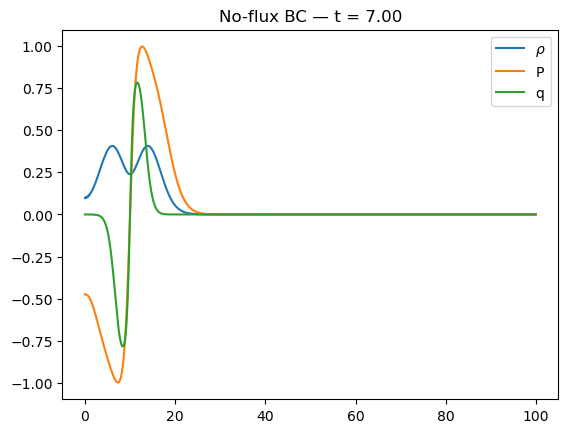

5.502710603520577


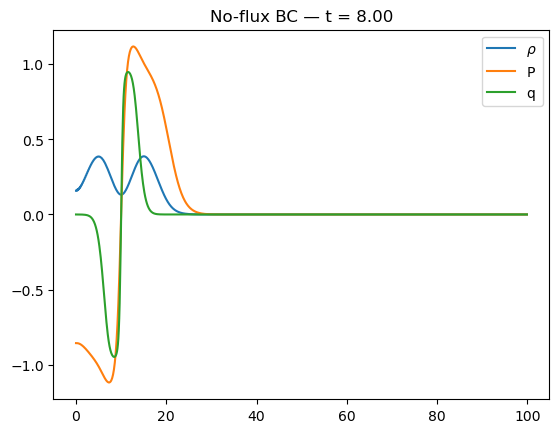

5.326034284899146


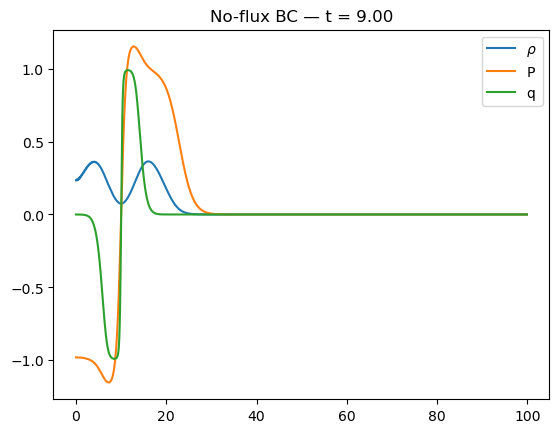

5.06883691468364


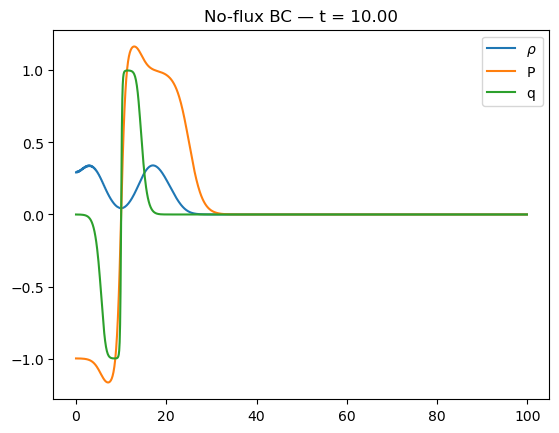

4.763986659312822


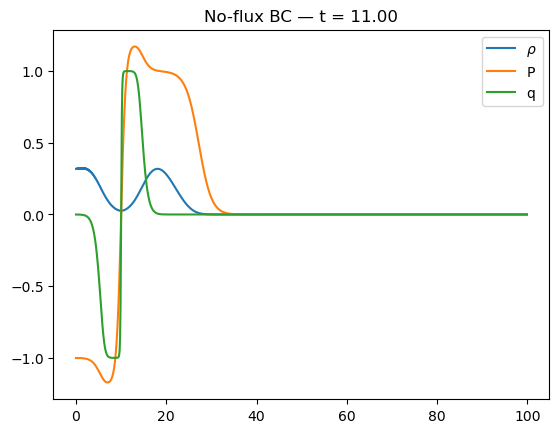

4.4446889407613135


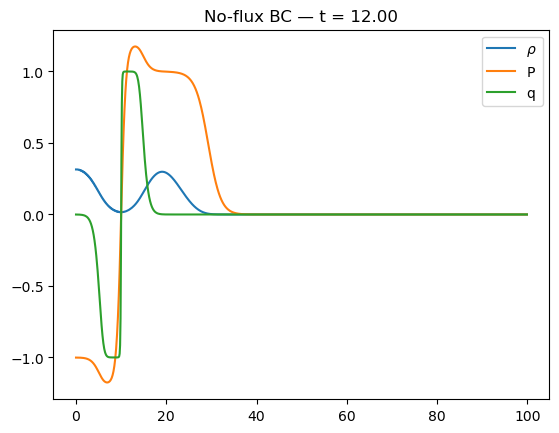

4.138270387379516


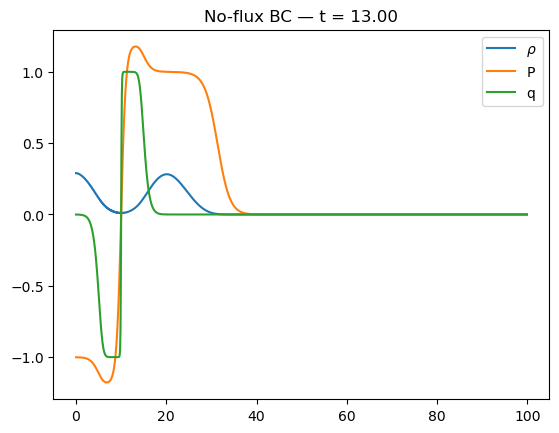

3.8628540561834757


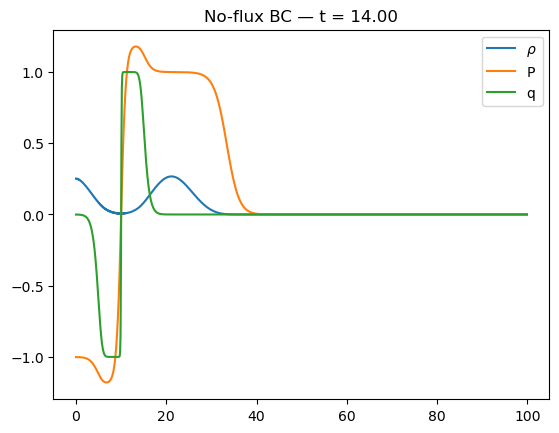

3.6273501137983346


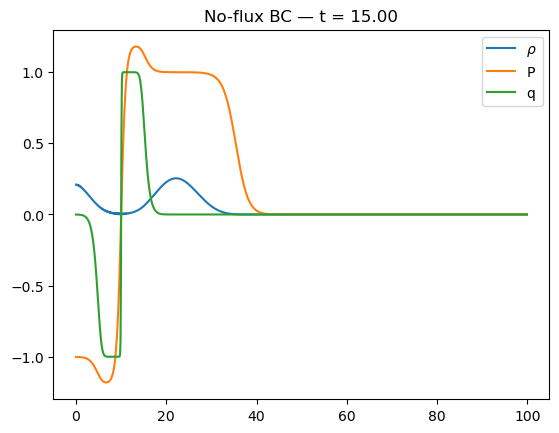

3.433543441711911


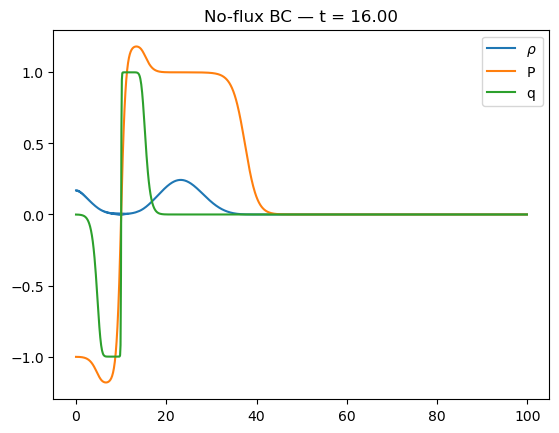

3.278710864943352


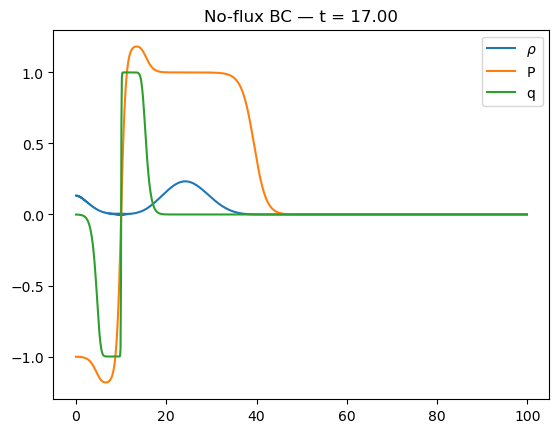

3.157846011715579


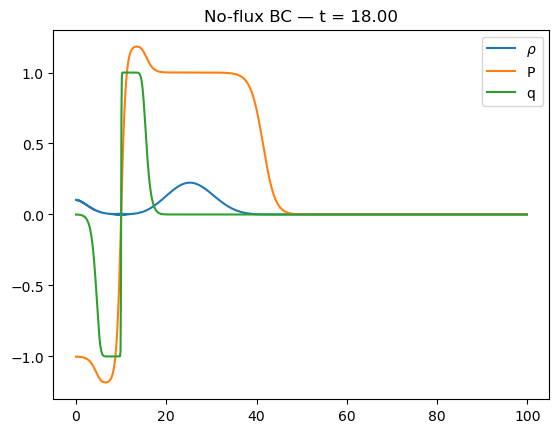

3.0652041753360804


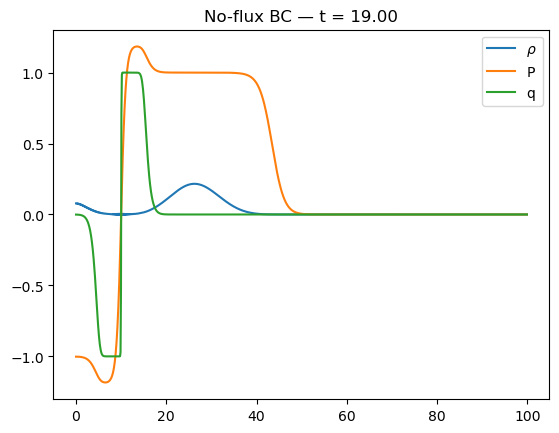

2.9952206350503254


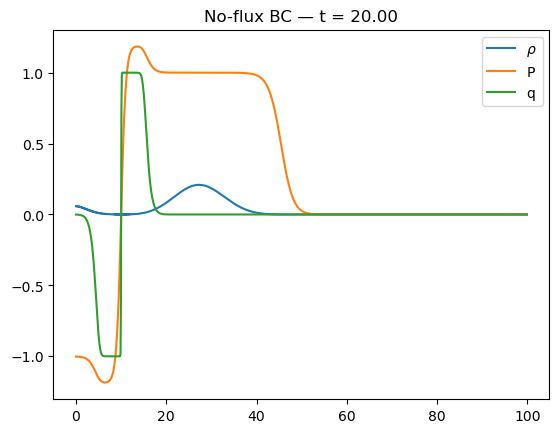

2.942969046708196


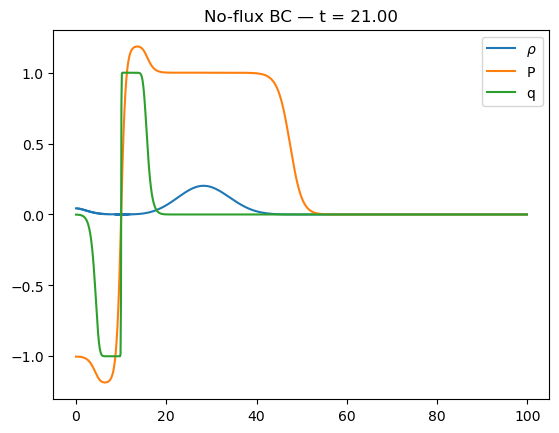

2.904326125816344


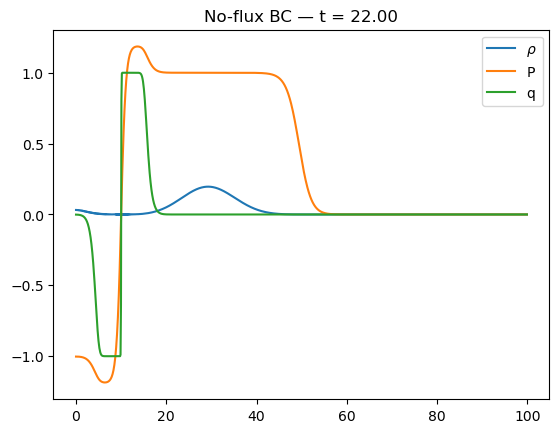

2.87596984934678


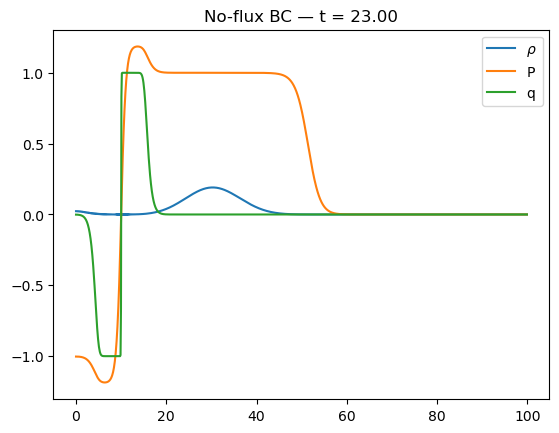

2.8552960187028633


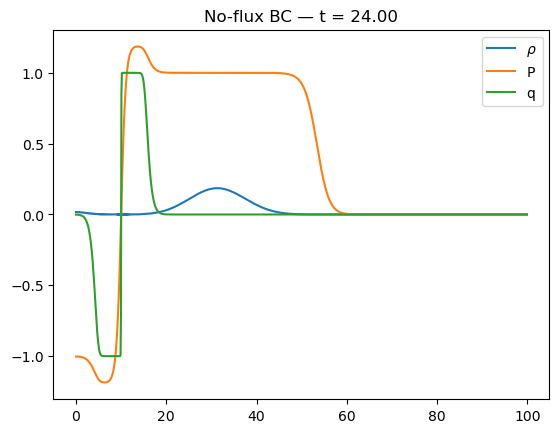

2.840304396667107


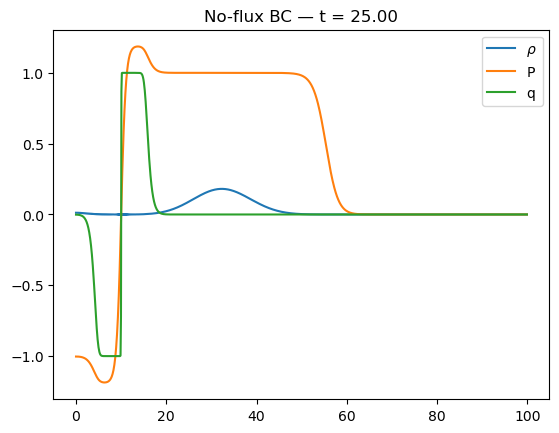

2.829482499018375


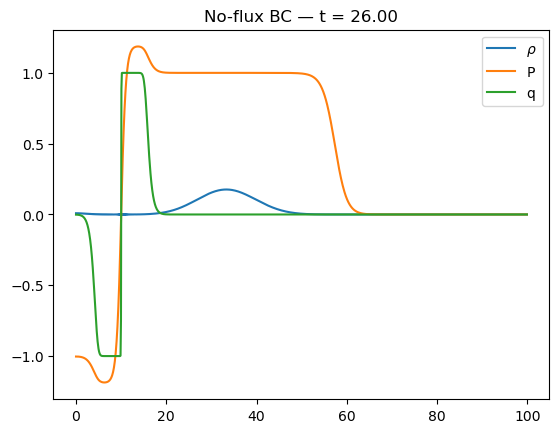

2.821700606290455


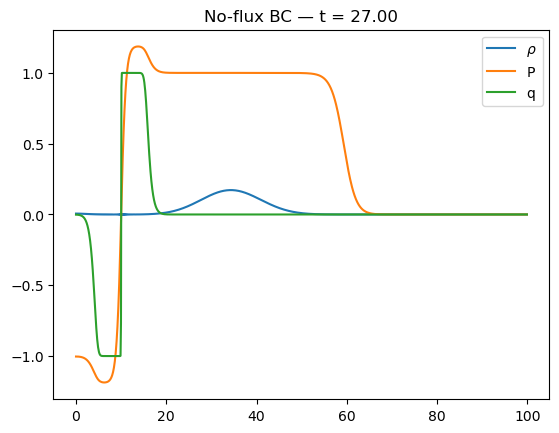

2.8161231220866147


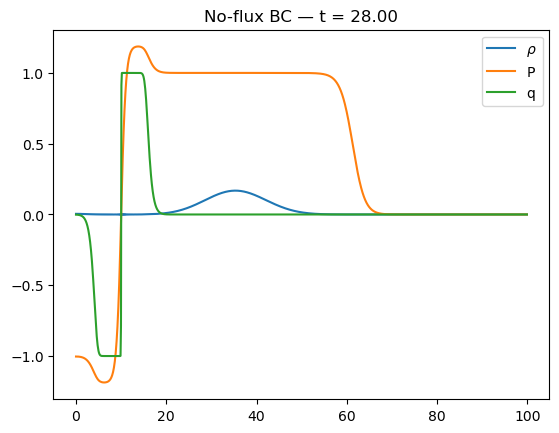

2.8121368834259717


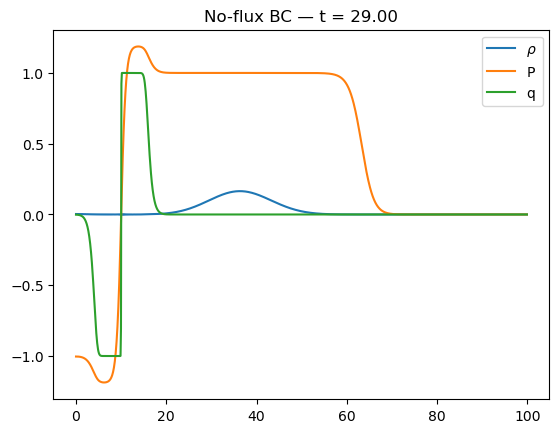

2.809294870816274


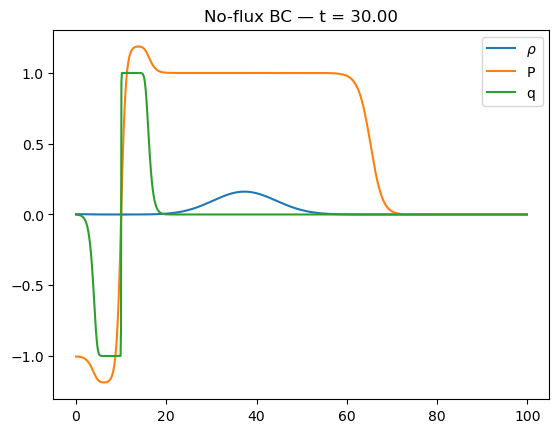

2.8072729471425606


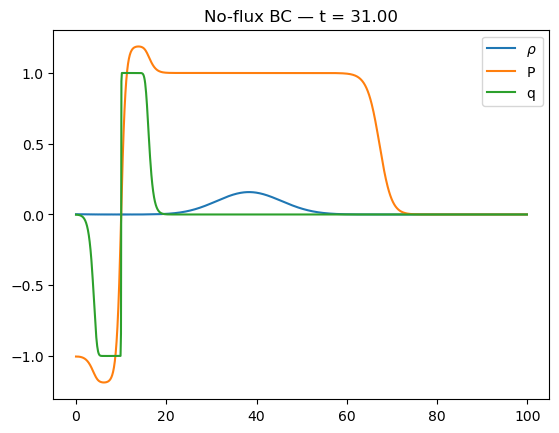

2.80583714137886


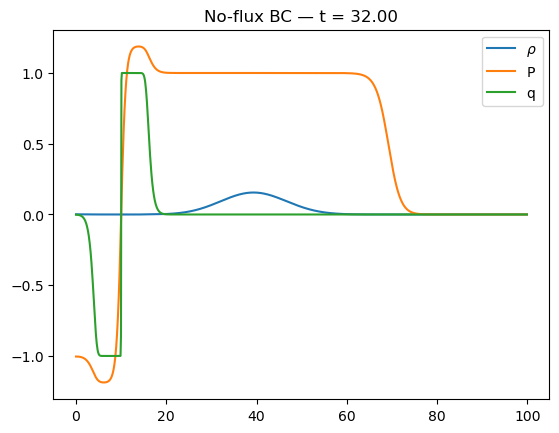

2.8048192134597034


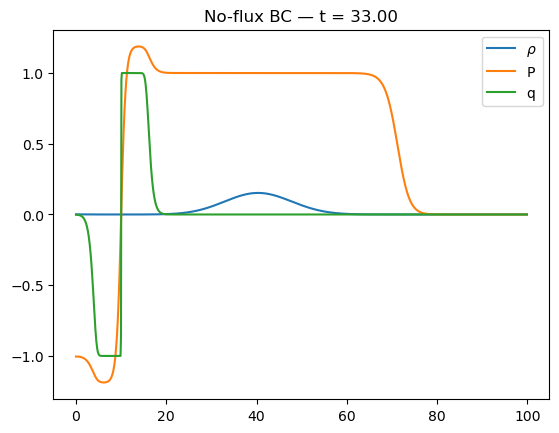

2.804098583290102


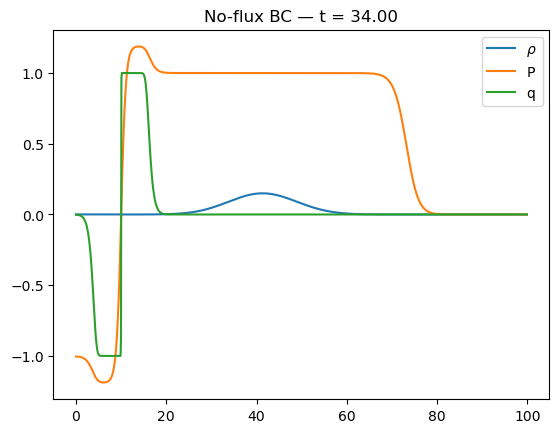

2.8035890720685916


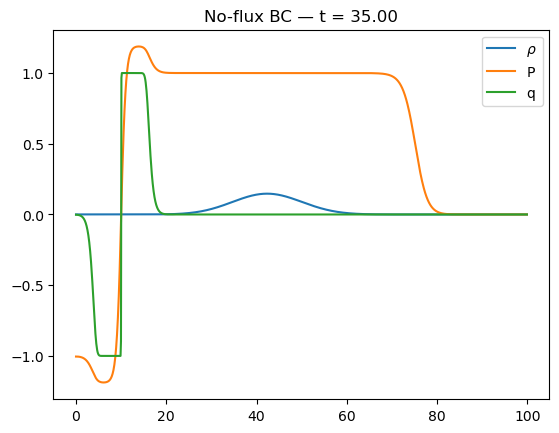

2.803229237350617


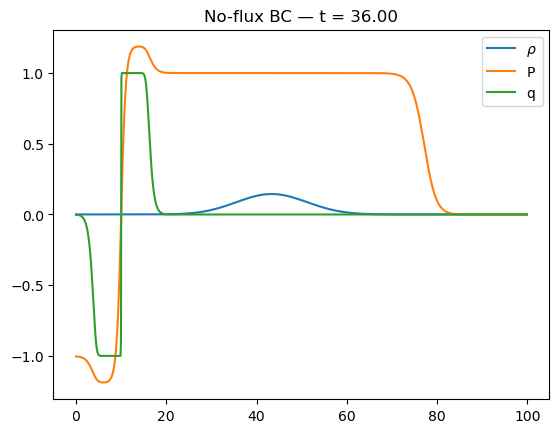

2.802975365545898


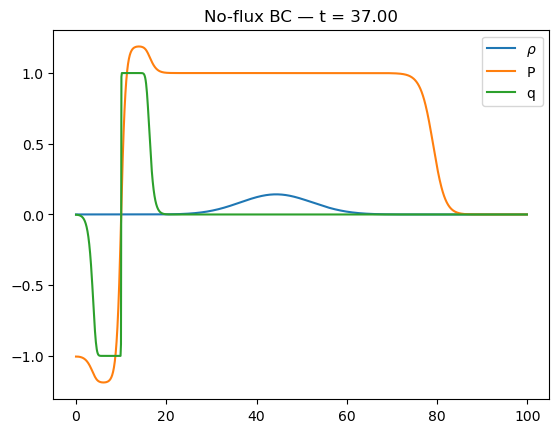

2.8027964139900226


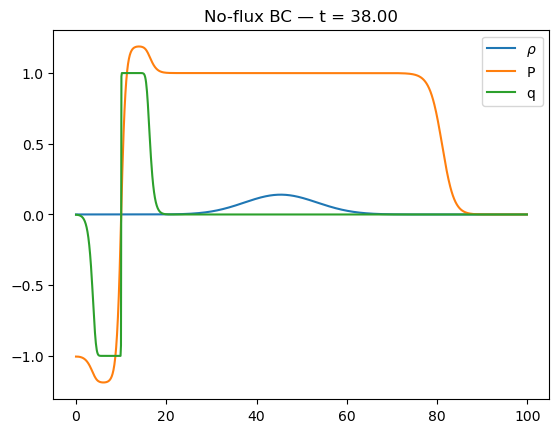

2.8026703740649492


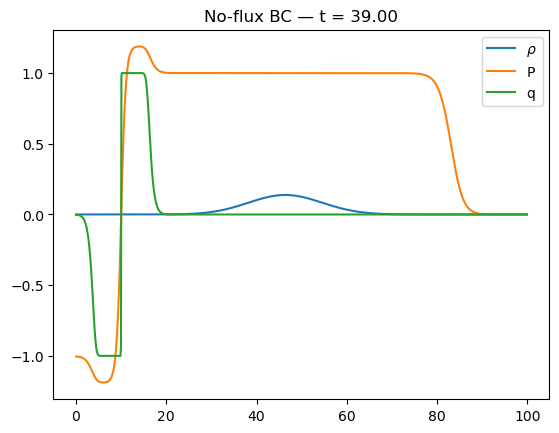

2.802581664597123


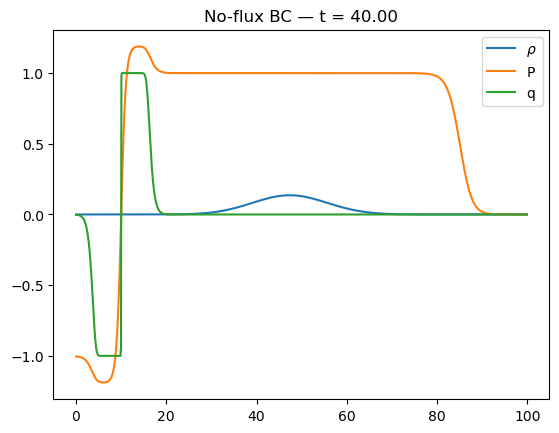

2.8025192688801464


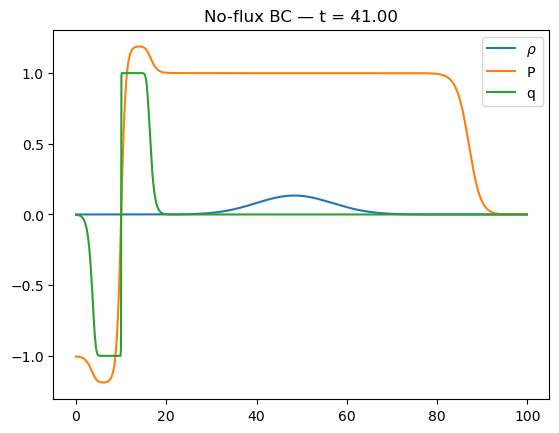

2.802475406394084


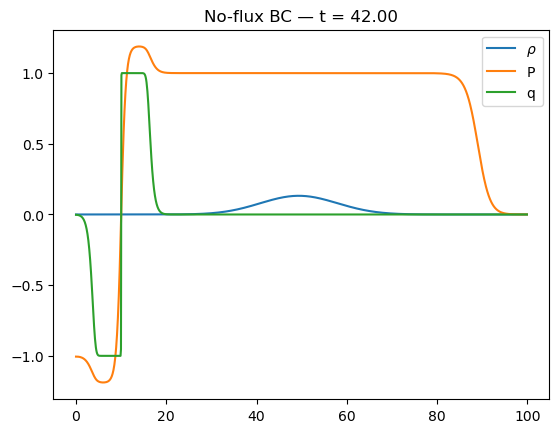

2.8024445877521673


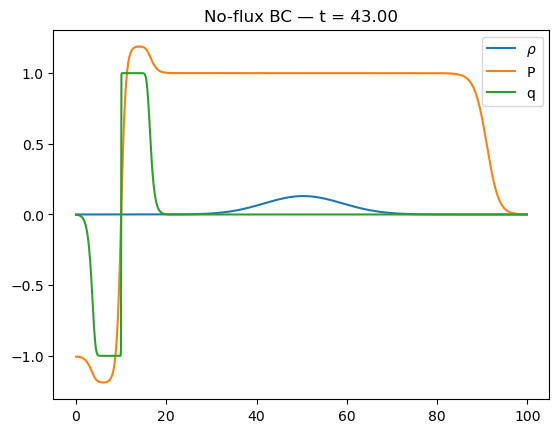

2.8024229435507286


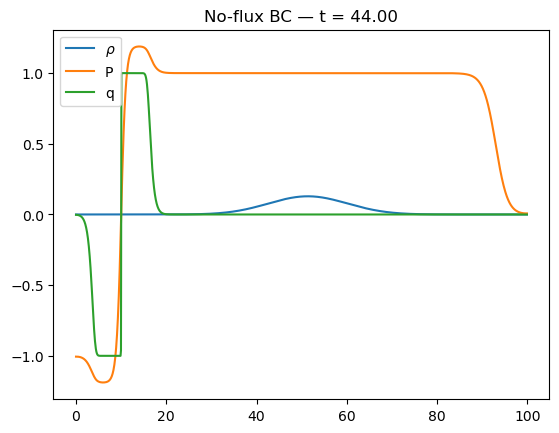

2.8024077485134824


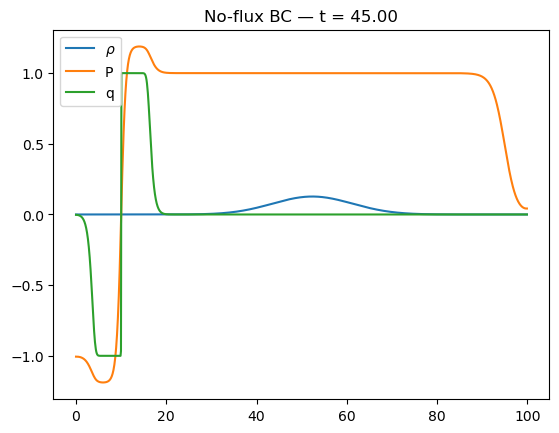

2.802397084555164


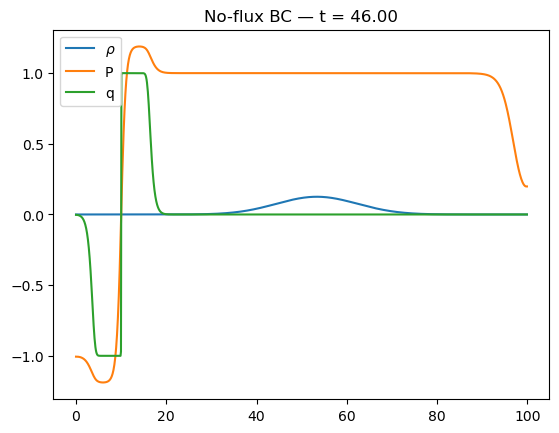

2.802389599927603


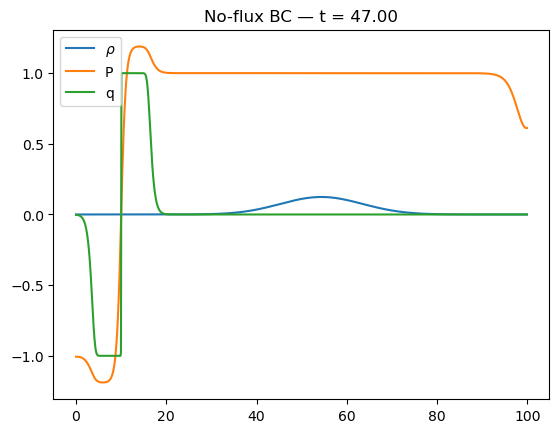

2.8023842887249097


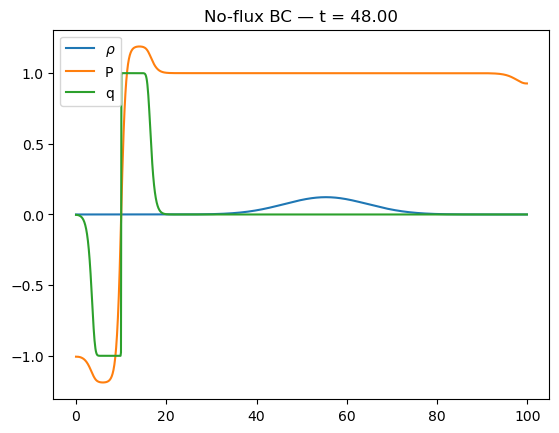

2.8023801917354603


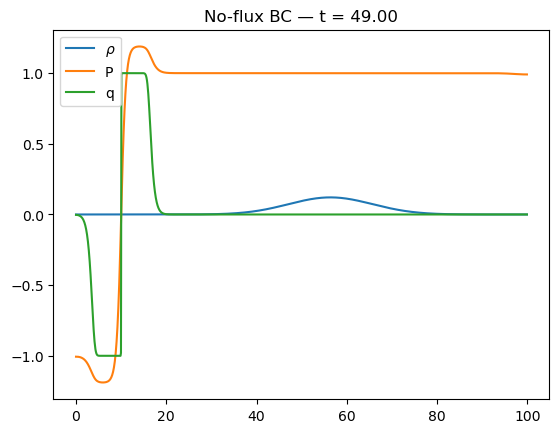

2.8023761472349085


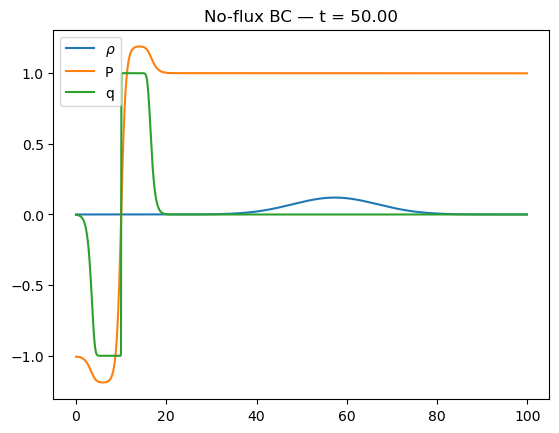

2.802370447263052


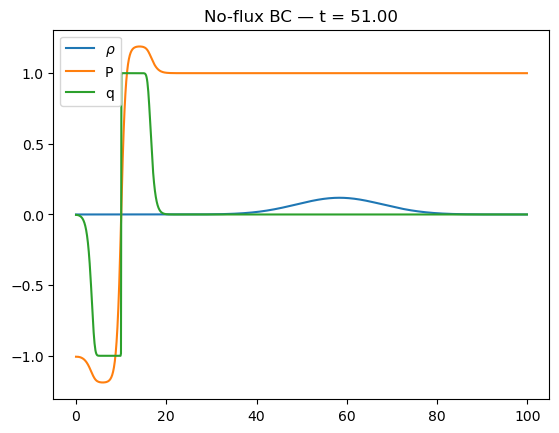

2.8023602655602775


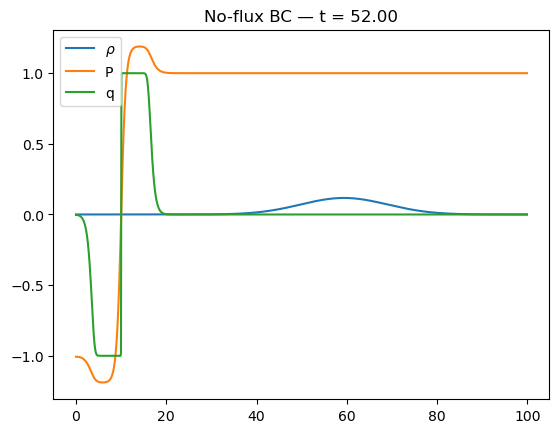

2.8023408260596705


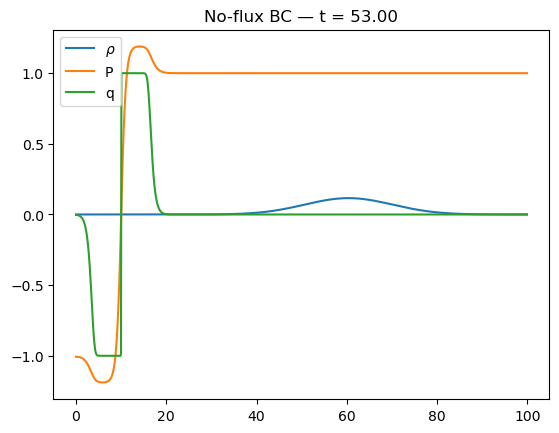

2.8023042298767487


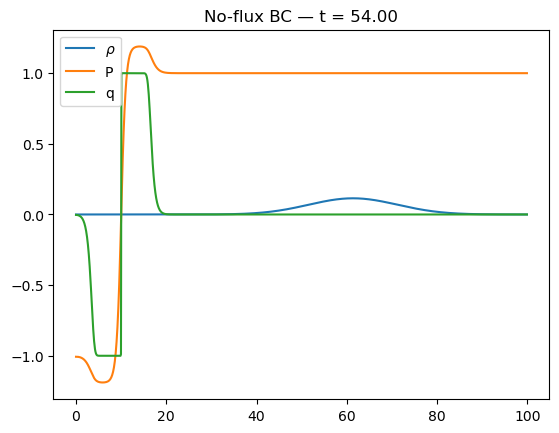

2.802237859871555


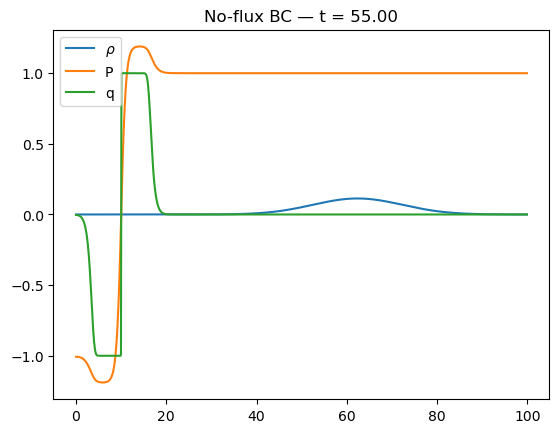

2.8021222994982935


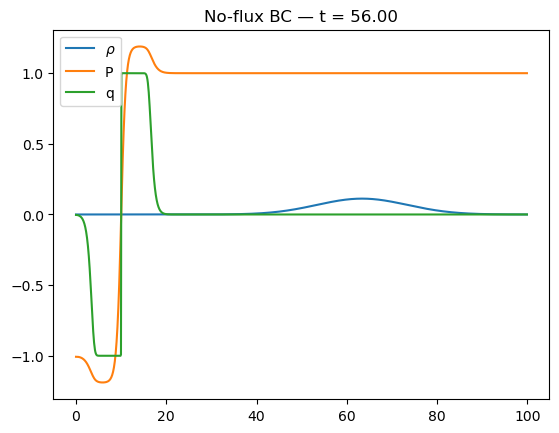

2.801928733288902


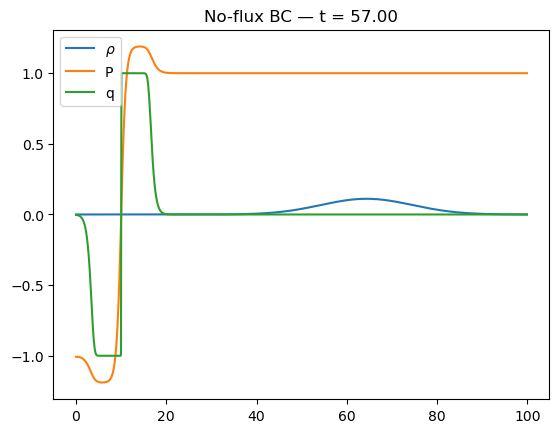

2.801615841306408


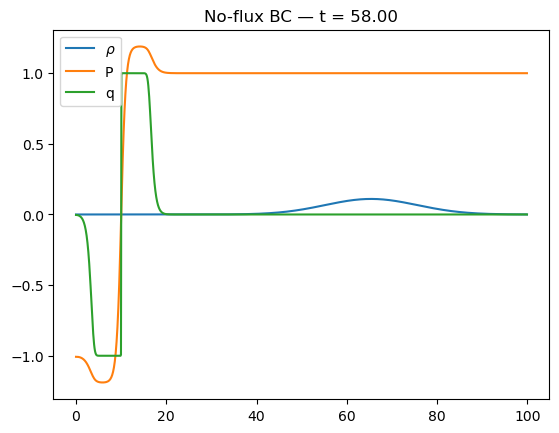

2.8011262575703855


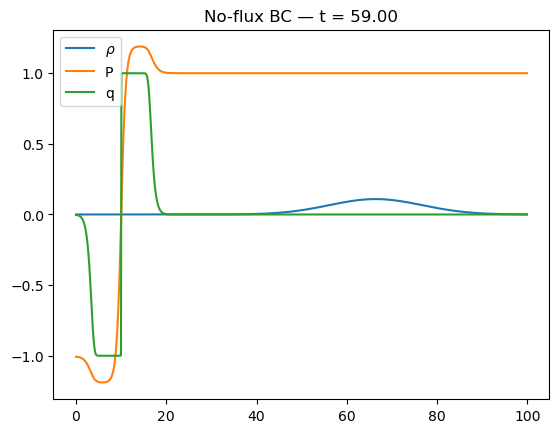

2.8003827285571594


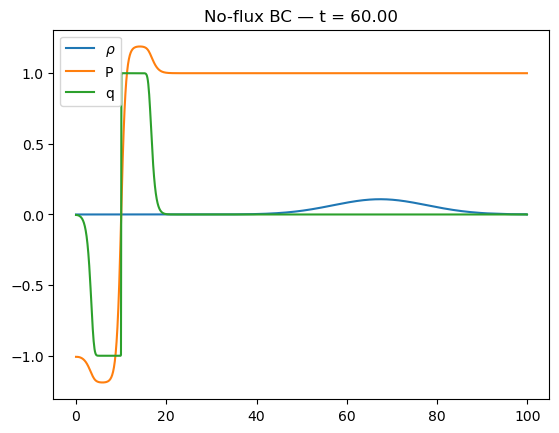

2.799284176045389


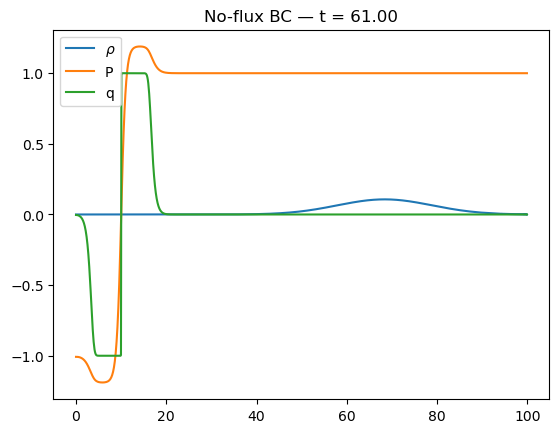

2.797701930992652


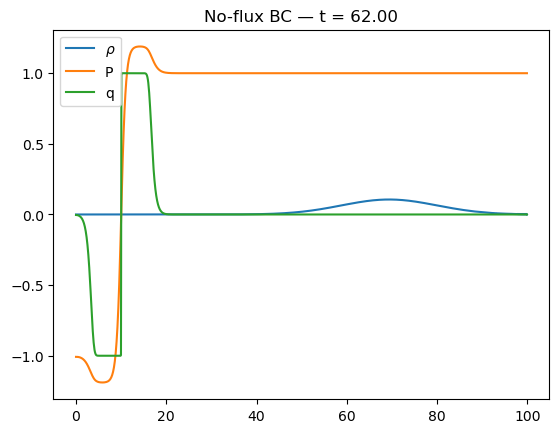

2.795476453476771


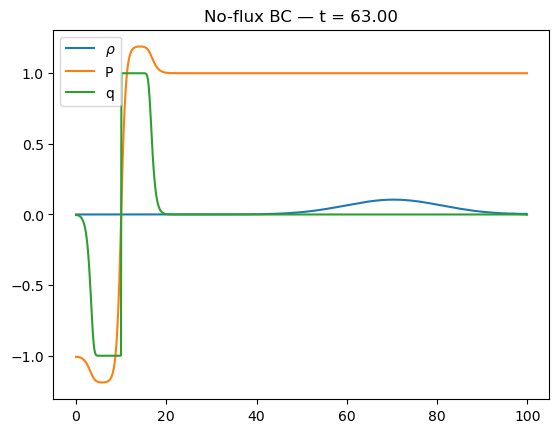

2.792414880335151


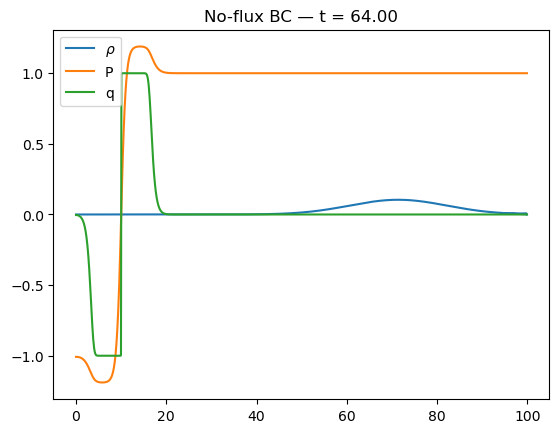

2.788289741049792


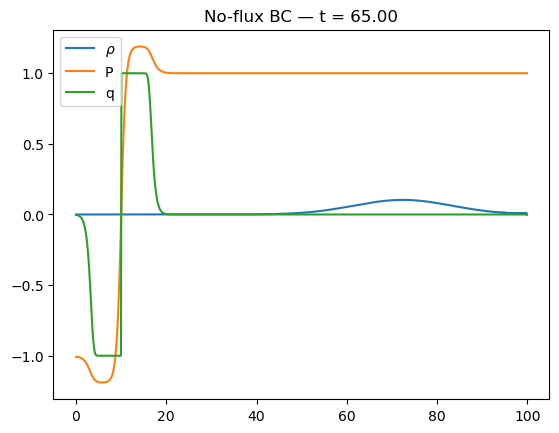

2.782839150380576


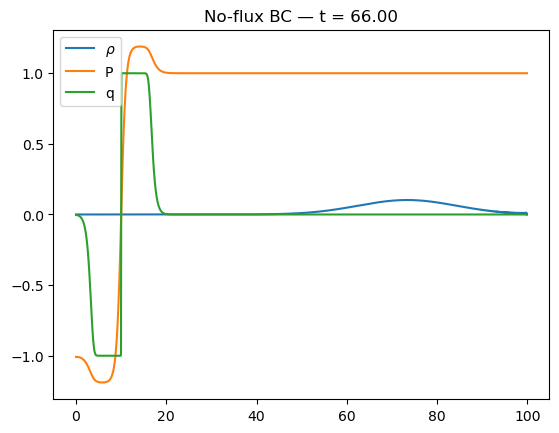

2.7757687232118666


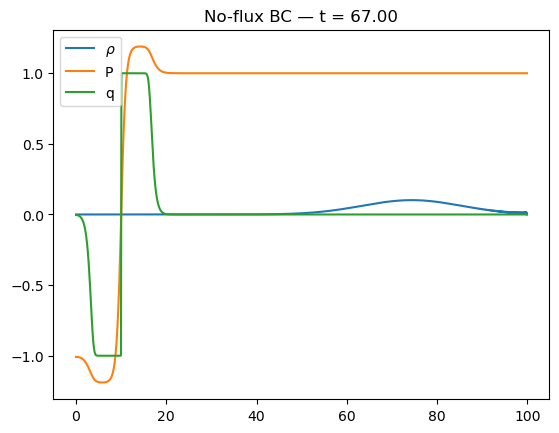

2.7667553664061497


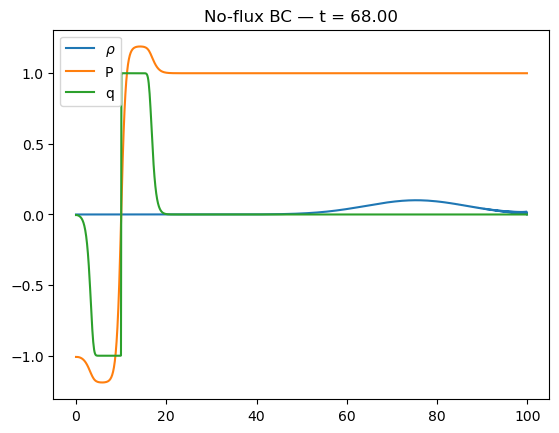

2.755452990611488


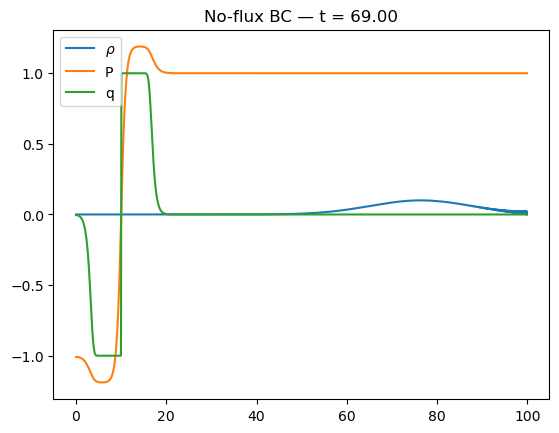

2.741500060818017


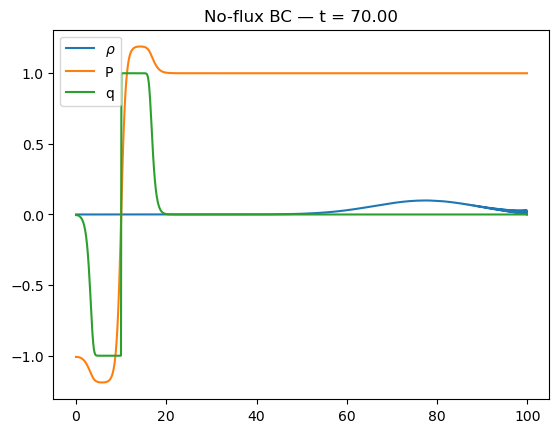

2.724528778314318


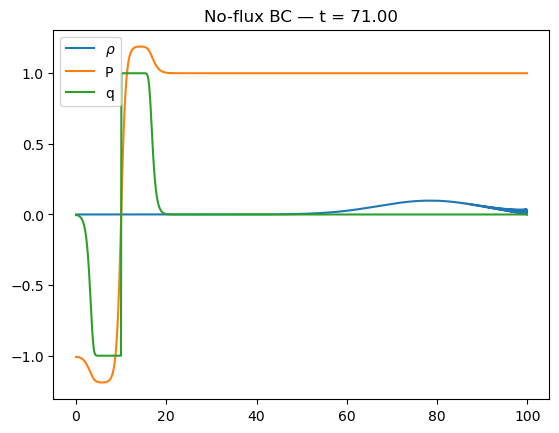

2.7041755691910705


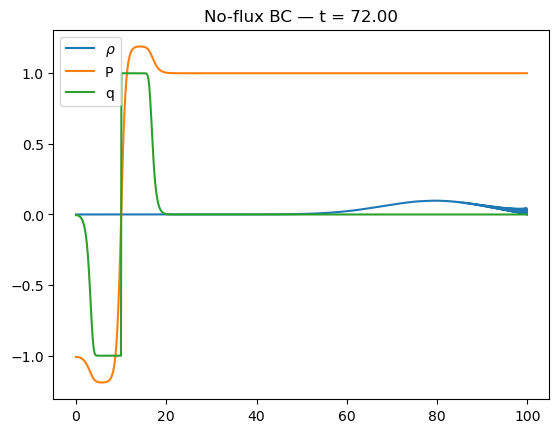

2.6800924555183165


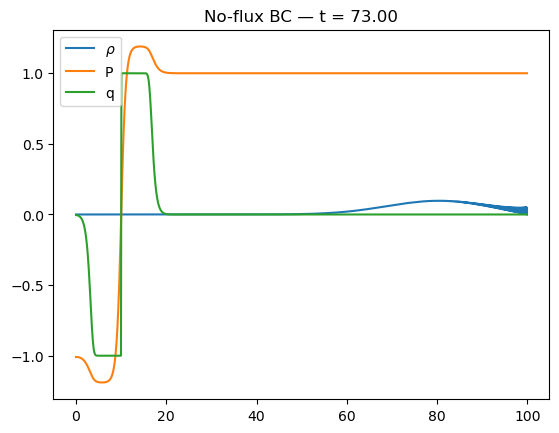

2.6519588128599687


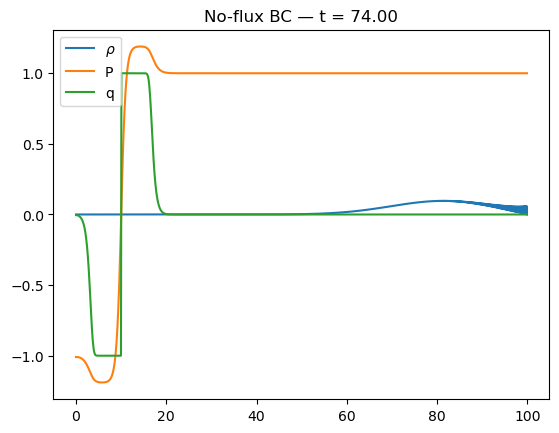

2.619492977469559


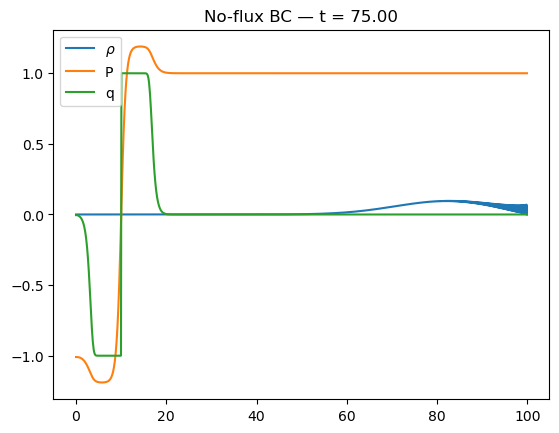

2.5824631610131736


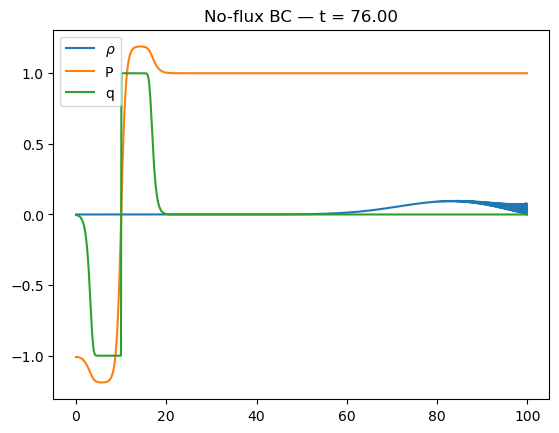

2.5406971596760934


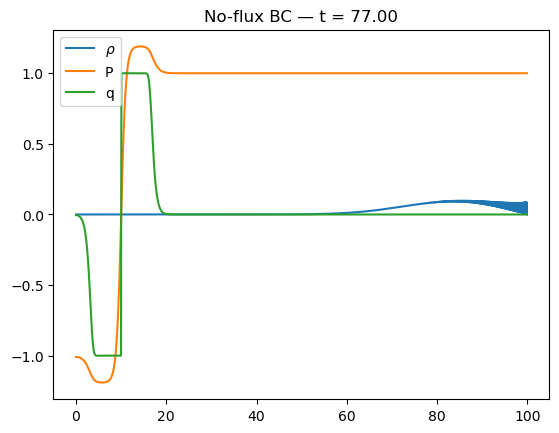

2.4940904049456654


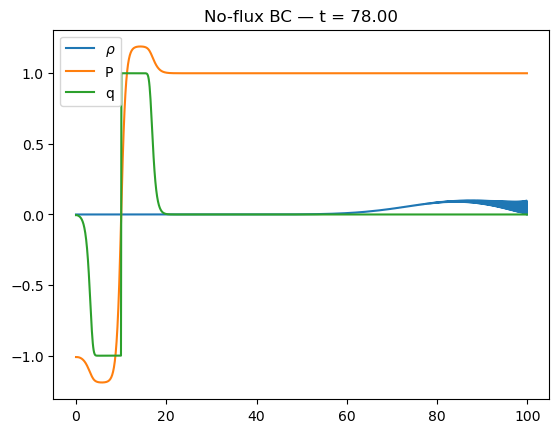

2.4426119898420273


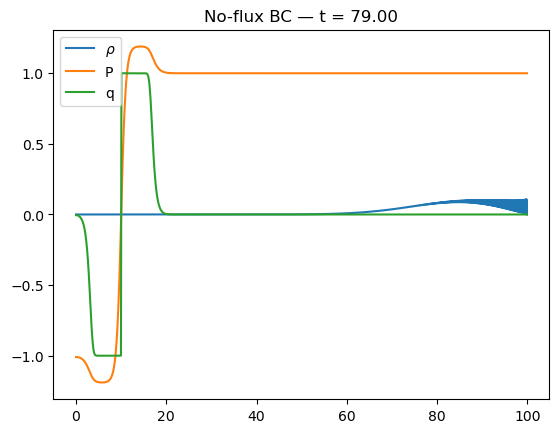

2.386308409853169


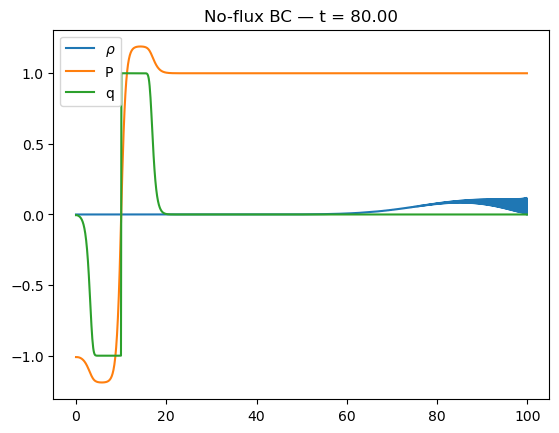

2.3253048743600333


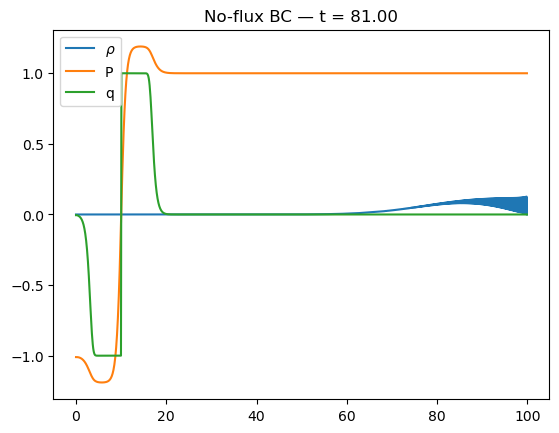

2.2598041637593025


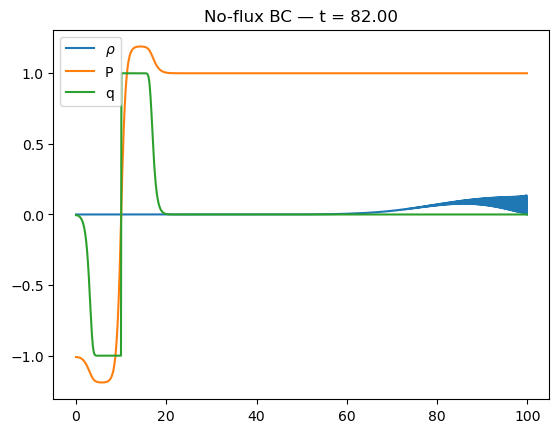

2.190083122130768


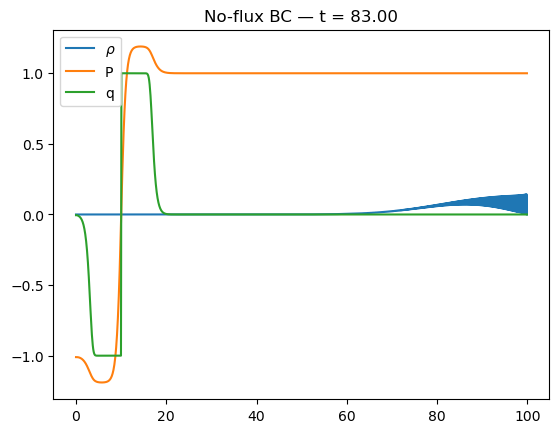

2.1164869784979916


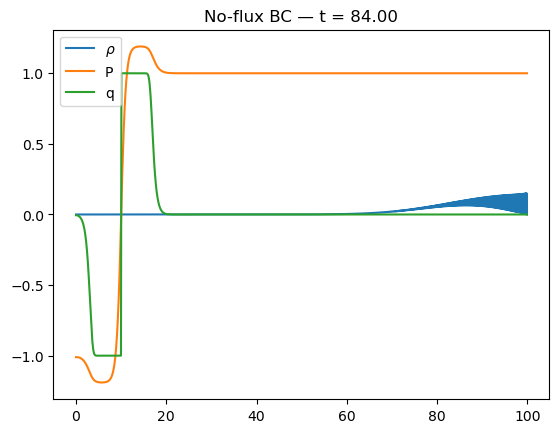

2.0394217762511864


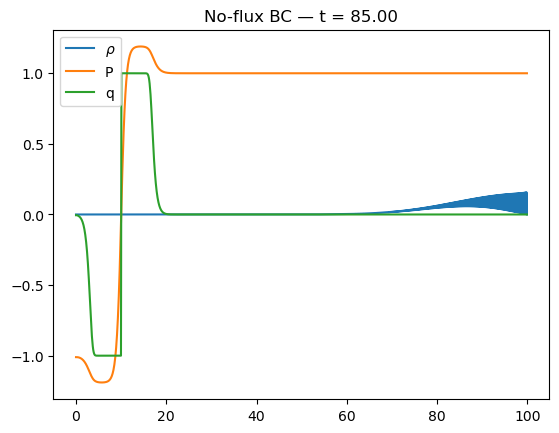

1.9593452565297536


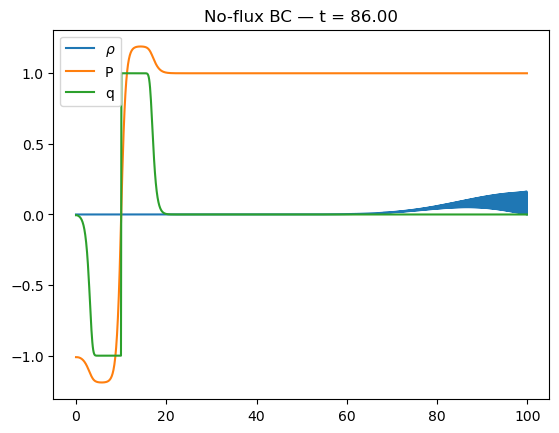

1.8767565853840402


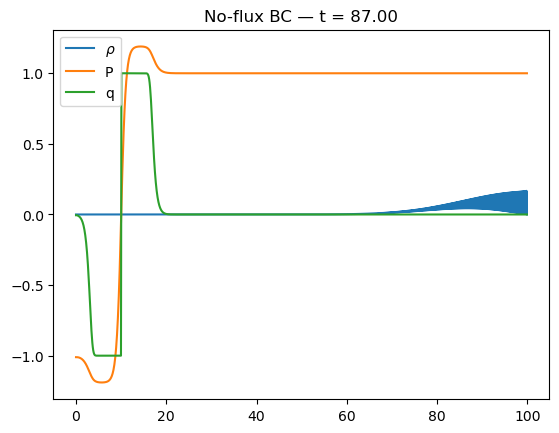

1.7921853360534652


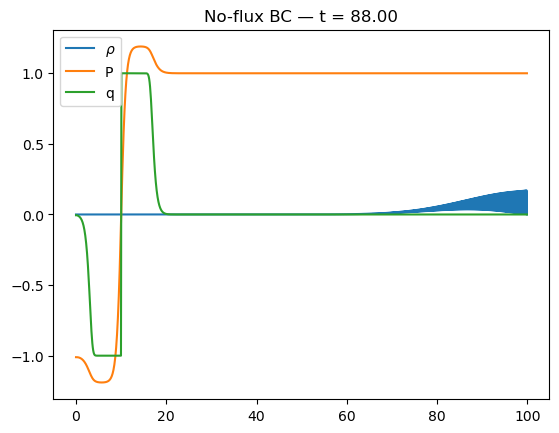

1.706180137837222


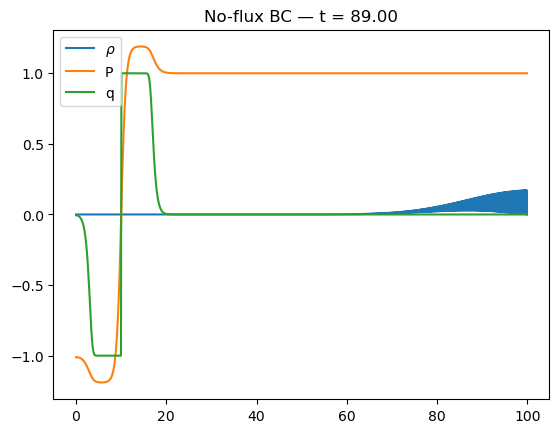

1.6192973840755724


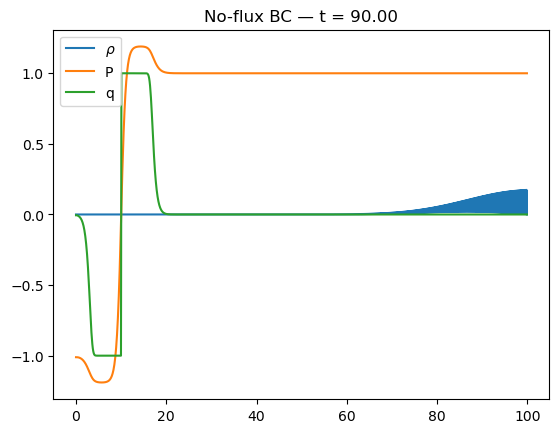

1.5320903568277517


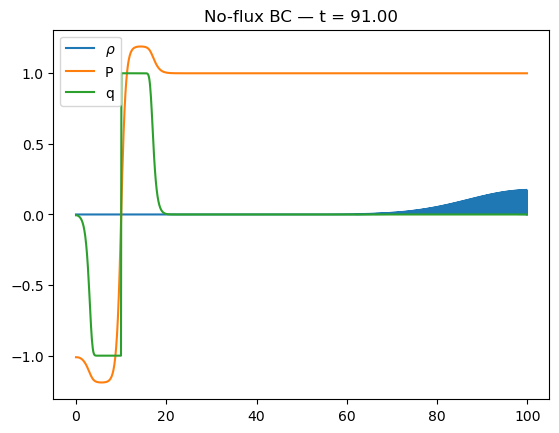

1.4450990785688755


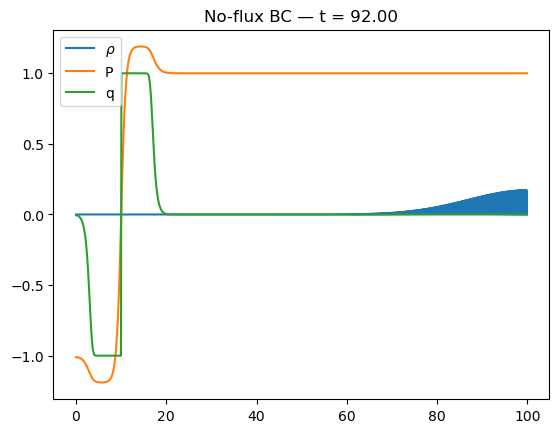

1.3588411454858167


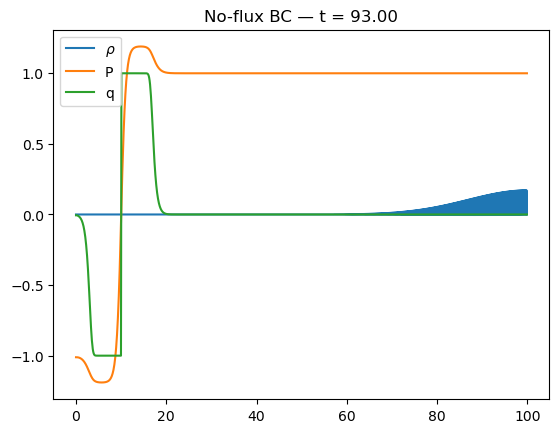

1.2738037365230264


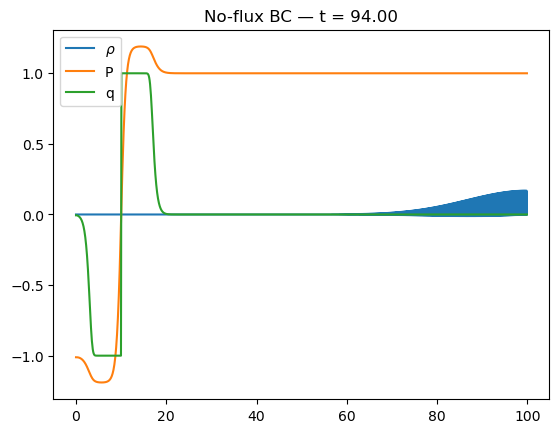

1.1904369307233857


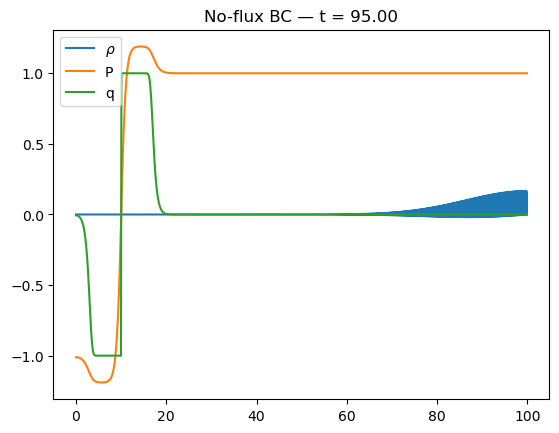

1.1091484056887935


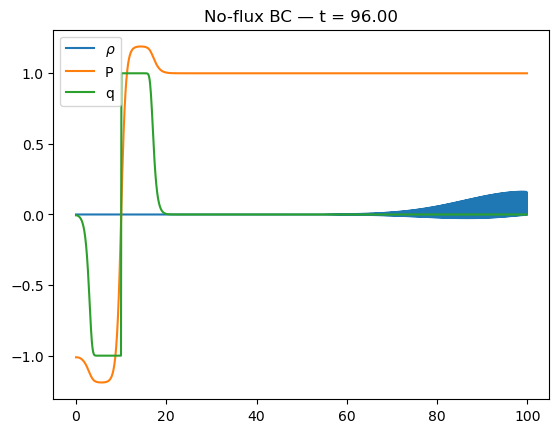

1.0302995346582988


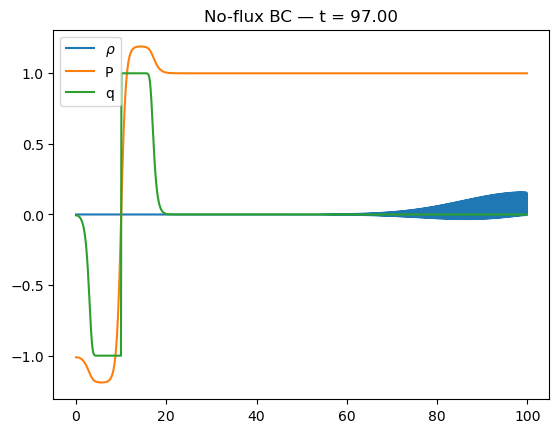

0.9542028506688982


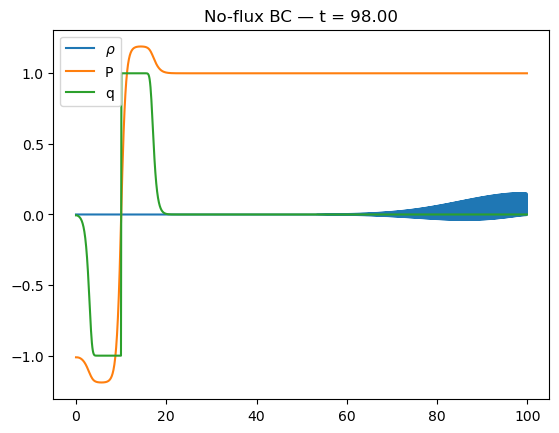

0.8811208048139828


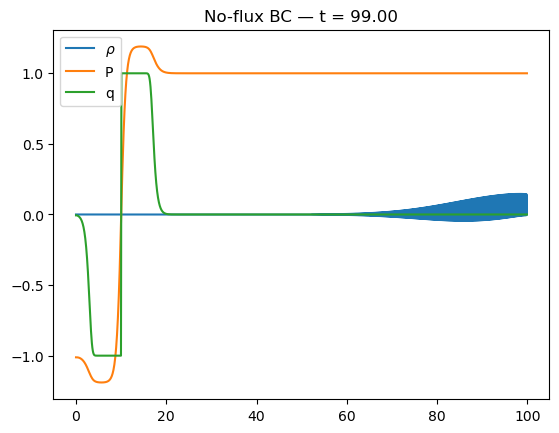

In [2]:

# Parameters
Nx = 1024
Lx = 100.0
dx = Lx / Nx
dt = 1e-3
Nt = 100_000

# Model parameters
a = -1.0
b = 1.0
K = 1.0
mu = 0.5
f = 1.0
D = 1.0

x = np.linspace(0, Lx, Nx, endpoint=False)

# Initial conditions
ci_rho = lambda x: np.exp(-(x - 10) ** 2 / 10)

rho = ci_rho(x)
P = -0.1 * np.gradient(rho)
q = np.zeros(Nx)

# ---------- Neumann boundary helper ----------
@njit
def apply_neumann(u):
    """Apply zero-flux (Neumann) BCs: du/dx = 0 at both boundaries."""
    # u[2] = 0
    # u[-3] = 0
    
    u[1] = u[2]
    u[0] = u[1]

    u[-2] = u[-3]
    u[-1] = u[-2]

# ---------- Spatial derivatives (no periodic rolls) ----------
@njit
def grad(u, dx):
    du = np.empty_like(u)
    # Central differences for interior
    du[1:-1] = (u[2:] - u[:-2]) / (2 * dx)
    du[0] = (u[1] - u[0]) / dx
    du[-1] = (u[-1] - u[-2]) / dx
    # Neumann BC (zero flux)
    du[0] = 0.0
    du[1] = 0.0
    du[-1] = 0.0
    du[-2] = 0.0
    return du

@njit
def laplacian(u, dx):
    N = u.shape[0]
    lap = np.empty_like(u)
    # interior
    for i in range(1, N-1):
        lap[i] = (u[i+1] - 2.0*u[i] + u[i-1]) / (dx*dx)
    # Neumann (zero gradient) -> mirror neighbors
    # we set second derivative at boundary equal to interior neighbor
    lap[0]   = (u[1] - 2.0*u[0] + u[1]) / (dx*dx)   # u[-1]=u[1]
    lap[-1]  = (u[-2] - 2.0*u[-1] + u[-2]) / (dx*dx)

    lap[0] = lap[1]
    lap[-1] = lap[-2]
    lap[1] = lap[2]
    lap[-2] = lap[-3]

    return lap


@njit
def step_rho(rho, P, dx, D):

    rhoP = rho * P
    d_rho = grad(rho, dx)

    J = rhoP - D * d_rho
    F = np.zeros(Nx + 1)
    for i in range(Nx + 1):
            F[i] = 0.5 * (J[i-1] + J[i])

    dif_F = np.zeros_like(rho)
    for i in range(Nx):
        dif_F[i] = - (F[i+1] - F[i]) / dx

    dif_F[0] = 0
    dif_F[-1] = 0

    return dif_F


# ---------- RHS ----------
@njit
def rhs(P, q, a, b, K, mu, f, D, dx):
    # apply_neumann(rho)
    apply_neumann(P)
    apply_neumann(q)

    dP = -a*P - b*P**3 + K*laplacian(P, dx) + mu*q
    dq = rho * P / f * (1 - q ** 2)
    return dP, dq

# ---------- RK4 time step ----------
@njit
def step(rho, P, q, a, b, K, mu, f, D, dx, dt):

    dif_F = step_rho(rho, P, dx, D)

    k1_P, k1_q = rhs(P, q, a, b, K, mu, f, D, dx)
    k2_P, k2_q = rhs(P + 0.5*dt*k1_P, q + 0.5*dt*k1_q, a, b, K, mu, f, D, dx)
    k3_P, k3_q = rhs(P + 0.5*dt*k2_P, q + 0.5*dt*k2_q, a, b, K, mu, f, D, dx)
    k4_P, k4_q = rhs(P + dt*k3_P, q + dt*k3_q, a, b, K, mu, f, D, dx)

    P_new   = P   + (dt/6)*(k1_P + 2*k2_P + 2*k3_P + k4_P)
    q_new   = q   + (dt/6)*(k1_q + 2*k2_q + 2*k3_q + k4_q)

    rho_new = rho + (dt) * dif_F
    rho_new[0] = rho_new[1]

    #apply_neumann(rho_new)
    apply_neumann(P_new)
    apply_neumann(q_new)


    return rho_new, P_new, q_new

rho_t = []
P_t = []
q_t = []

rho_t.append(rho)
P_t.append(P)
q_t.append(q)

# ---------- Time evolution ----------
for n in range(Nt):
    rho, P, q = step(rho, P, q, a, b, K, mu, f, D, dx, dt)

    if n % int(1 / dt) == 0:
        
        rho_t.append(rho)
        P_t.append(P)
        q_t.append(q)
    if n % 1000 == 0:
        print(np.sum(rho)*dx)
        plt.clf()
        plt.plot(x, rho, label=r'$\rho$')
        plt.plot(x, P, label='P')
        plt.plot(x, q, label='q')
        plt.legend()
        plt.title(f"No-flux BC — t = {n*dt:.2f}")
        plt.pause(0.01)

plt.show()

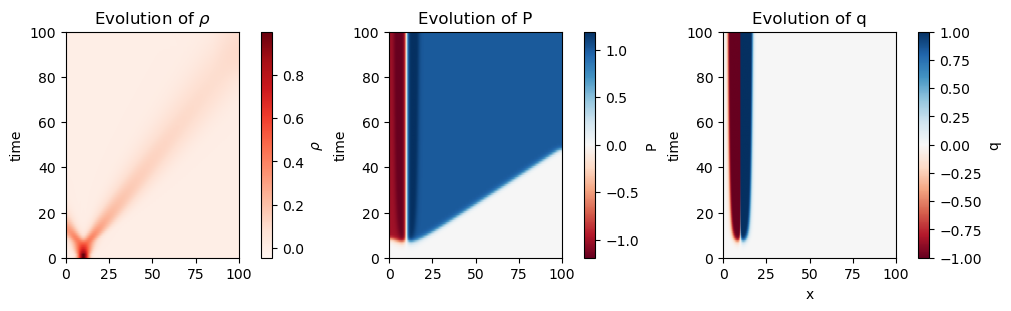

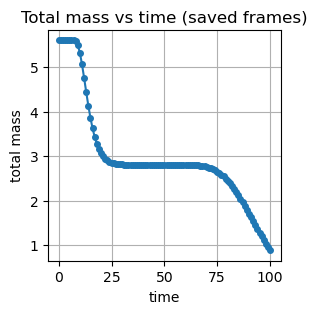

In [3]:
# stack saved snapshots (rho_t, P_t, q_t are lists of 1D arrays)
rho_arr = np.vstack(rho_t)   # shape (nt_save, Nx)
P_arr   = np.vstack(P_t)
q_arr   = np.vstack(q_t)

nt_save = rho_arr.shape[0]


save_interval_steps = 1 / dt
times = np.arange(nt_save) * (dt * save_interval_steps)

extent = [x[0], x[-1] + dx, times[0], times[-1]]  # x axis left->right, y axis time increasing upward
fig, axs = plt.subplots(1, 3, figsize=(10,3), constrained_layout=True)
im0 = axs[0].imshow(rho_arr, aspect='auto', extent=extent, origin='lower', cmap='Reds')
axs[0].set_ylabel('time')
axs[0].set_title(r'Evolution of $\rho$')
fig.colorbar(im0, ax=axs[0], label=r'$\rho$')

im1 = axs[1].imshow(P_arr, aspect='auto', extent=extent, origin='lower', cmap='RdBu')
axs[1].set_ylabel('time')
axs[1].set_title('Evolution of P')
fig.colorbar(im1, ax=axs[1], label='P')

im2 = axs[2].imshow(q_arr, aspect='auto', extent=extent, origin='lower', cmap='RdBu')
axs[2].set_xlabel('x')
axs[2].set_ylabel('time')
axs[2].set_title('Evolution of q')
fig.colorbar(im2, ax=axs[2], label='q')

plt.show()

# plot total mass over saved frames to check conservation
mass = [np.sum(r)*dx for r in rho_t]
plt.figure(figsize=(3,3))
plt.plot(times, mass, '-o', markersize=4)
plt.xlabel('time')
plt.ylabel('total mass')
plt.title('Total mass vs time (saved frames)')
plt.grid(True)
plt.show()

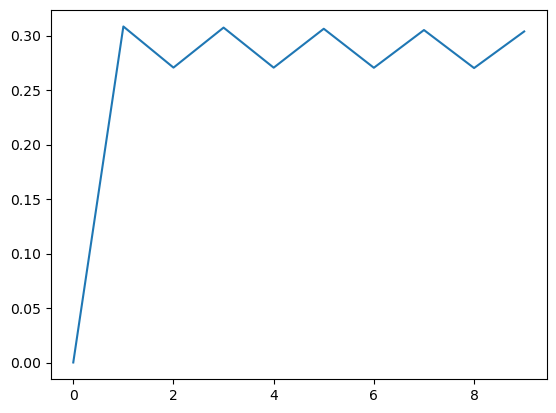

In [77]:
plt.plot(rho[0:10])
 # plt.plot(rho)
